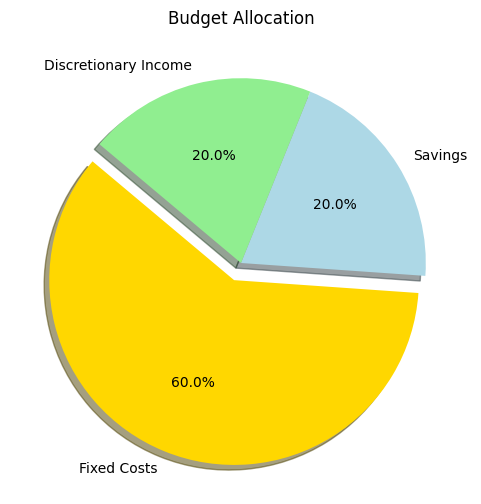

In [ ]:
import matplotlib.pyplot as plt

labels = ['Fixed Costs', 'Savings', 'Discretionary Income']
sizes = [1500, 500, 500]
colors = ['gold', 'lightblue', 'lightgreen']
explode = (0.1, 0, 0)

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Budget Allocation')
plt.show()


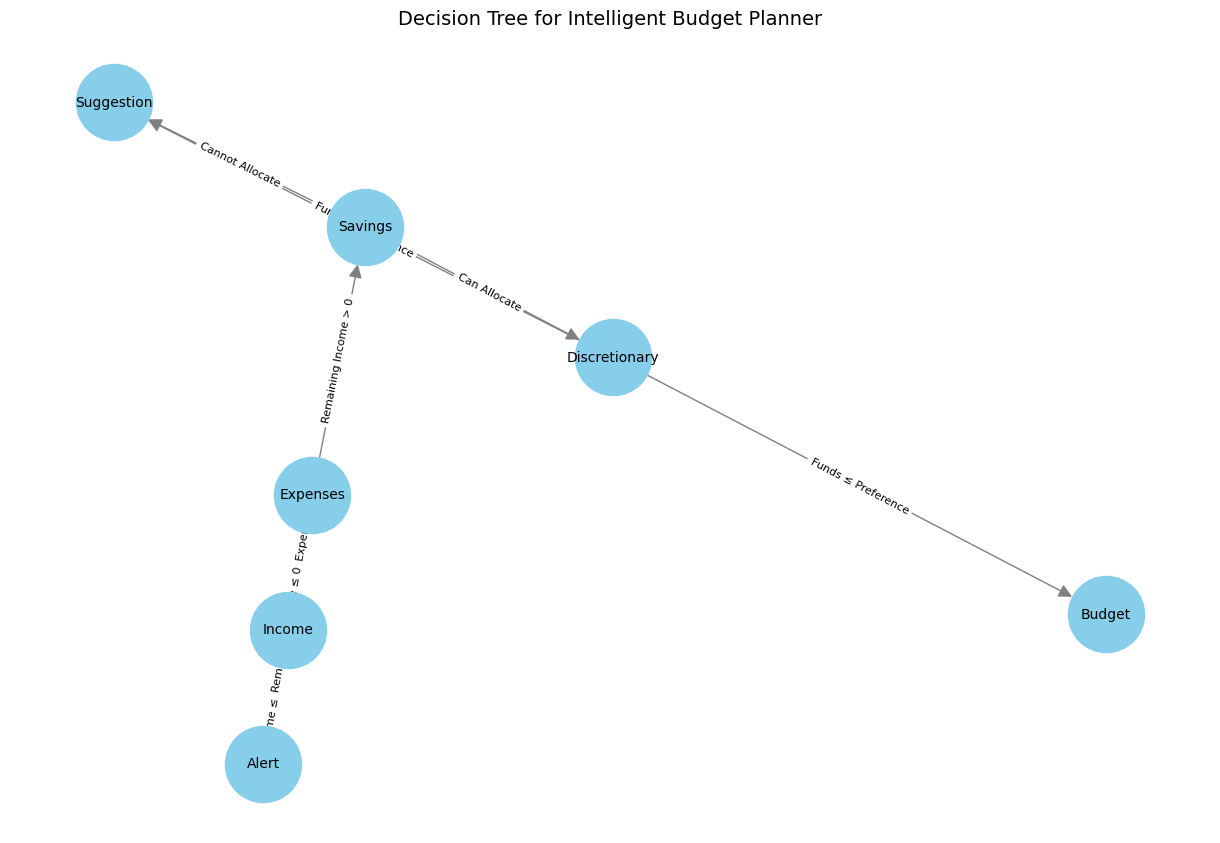

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

G.add_edge("Income", "Expenses", label="Income > Expenses")
G.add_edge("Income", "Alert", label="Income ≤ Expenses")
G.add_edge("Expenses", "Savings", label="Remaining Income > 0")
G.add_edge("Expenses", "Alert", label="Remaining Income ≤ 0")
G.add_edge("Savings", "Discretionary", label="Can Allocate")
G.add_edge("Savings", "Suggestion", label="Cannot Allocate")
G.add_edge("Discretionary", "Budget", label="Funds ≤ Preference")
G.add_edge("Discretionary", "Suggestion", label="Funds > Preference")

pos = nx.spring_layout(G, seed=42)
labels = nx.get_edge_attributes(G, "label")

plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=3000, font_size=10, edge_color="gray", arrowsize=20)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)

plt.title("Decision Tree for Intelligent Budget Planner", fontsize=14)
plt.savefig("decision_tree.png")
plt.show()


In [ ]:
def intelligent_budget_planner(income, fixed_costs, savings_goal_percent):

    if income <= 0 or fixed_costs < 0 or savings_goal_percent < 0:
        return "Error: Invalid input values. Ensure all inputs are positive numbers."

    if fixed_costs > income:
        return "Alert: Fixed costs exceed income. Reduce fixed expenses to balance your budget."


In [ ]:
def intelligent_budget_planner(income, fixed_costs, savings_goal_percent):
    """
    A budget planner that calculates savings and discretionary income,
    and provides recommendations to optimize financial decisions.
    """

    if income <= 0 or fixed_costs < 0 or savings_goal_percent < 0:
        return "Error: Invalid input values. Ensure all inputs are positive numbers."

    if fixed_costs > income:
        return "Alert: Fixed costs exceed income. Reduce fixed expenses to balance your budget."

    remaining_income = income - fixed_costs

    savings_goal = (savings_goal_percent / 100) * income
    if savings_goal > remaining_income:
        return (f"Suggestion: Your savings goal of ${savings_goal:.2f} exceeds available funds "
                f"(${remaining_income:.2f}). Adjust your goal or reduce fixed costs.")

    discretionary_income = remaining_income - savings_goal
    if discretionary_income < 0:
        return ("Suggestion: Consider reducing your savings goal or fixed expenses to allow for "
                "discretionary spending.")

    budget_plan = {
        "Fixed Costs": f"${fixed_costs:.2f}",
        "Savings Allocated": f"${savings_goal:.2f}",
        "Discretionary Spending": f"${discretionary_income:.2f}",
        "Remaining Income": f"${remaining_income:.2f}"
    }

    advice = "Budget is balanced. Focus on meeting your savings goals consistently."

    return budget_plan, advice


income = 2500
fixed_costs = 1500
savings_goal_percent = 20

planner_output = intelligent_budget_planner(income, fixed_costs, savings_goal_percent)

if isinstance(planner_output, tuple):
    budget, advice = planner_output
    print("Budget Plan:", budget)
    print("Advice:", advice)
else:
    print(planner_output)

Budget Plan: {'Fixed Costs': '$1500.00', 'Savings Allocated': '$500.00', 'Discretionary Spending': '$500.00', 'Remaining Income': '$1000.00'}
Advice: Budget is balanced. Focus on meeting your savings goals consistently.
